<a href="https://colab.research.google.com/github/alexislagasca/Phase3AlexisLagasca/blob/main/Phase_3_Model_Selection%2C_Training%2C_and_Evaluation_NegativeResultOnly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Upload dataset
from google.colab import files
import pandas as pd
import numpy as np
df = pd.read_csv('https://github.com/alexislagasca/phase3lagasca/raw/refs/heads/main/NegativeResultOnly(Sheet%203%20All%20Data).csv')
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

print("✓ Setup complete!")

✓ Setup complete!


In [2]:
#Basic data information
print("="*80)
print("DATA OVERVIEW")
print("="*80)

print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"Duplicated Rows: {df.duplicated().sum()}")

#Check target variable
print("\n" + "="*80)
print("TARGET VARIABLE (Final Status)")
print("="*80)
print(df['Final Status'].value_counts())
print(f"\nClass Distribution:\n{df['Final Status'].value_counts(normalize=True)}")

DATA OVERVIEW

Dataset Shape: (12091, 29)

Column Names:
['Case_Id', 'Age', 'Min-Max Scaling Age', 'Age_Group', 'Age_Group(0,1,2)', 'Min-Max Scaling Age Group', 'Sex', 'Sex(0,1)', 'Province', 'Municipality', 'Region', 'Island', 'Region (0,1,2)', 'Min-Max Region', 'Region_NCR', 'Pregnant', 'Pregnant(0,1,2)', 'Min-Max Pregnant', 'Status', 'Status Severity', 'Min-Max Status Severity', 'Health_Status', 'Health_Status(0,1,2,3,4,5)', 'Min-Max Health Status', 'High_Risk', 'Is_Symptomatic', 'Mortality Risk', 'Min-Max Mortality Risk', 'Final Status']

Data Types:
Case_Id                        object
Age                             int64
Min-Max Scaling Age           float64
Age_Group                      object
Age_Group(0,1,2)                int64
Min-Max Scaling Age Group     float64
Sex                            object
Sex(0,1)                        int64
Province                       object
Municipality                   object
Region                         object
Island               

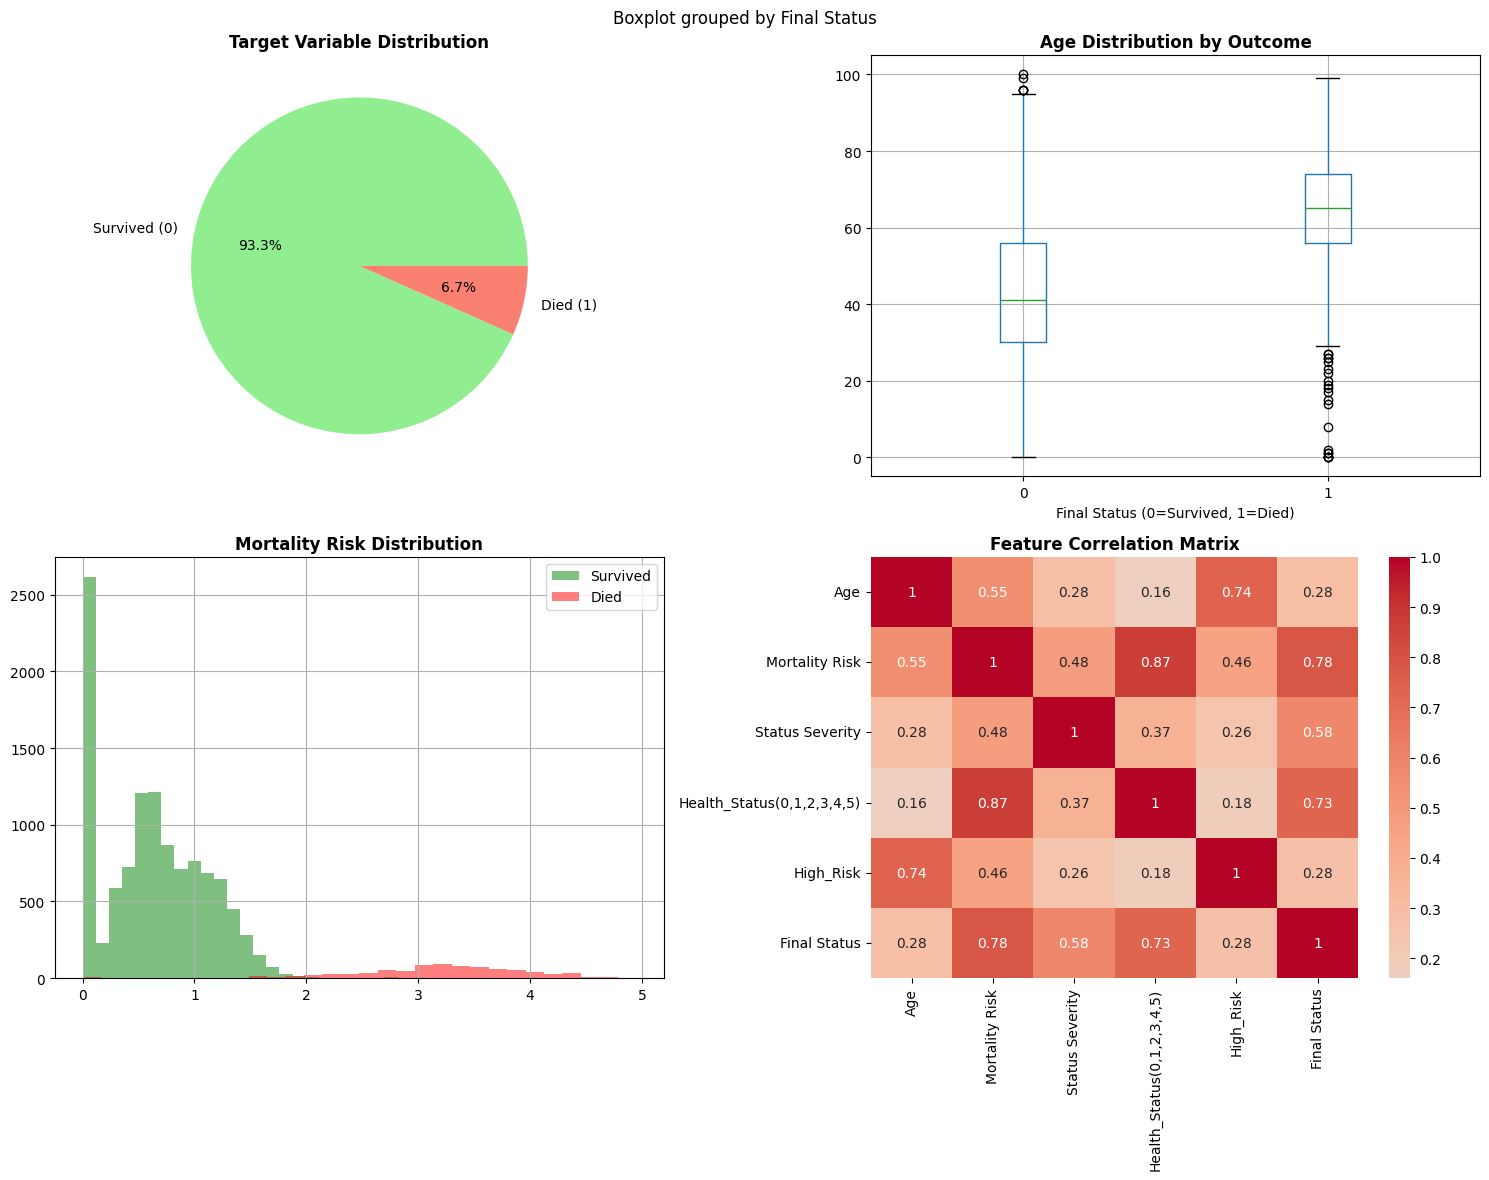

✓ Saved: data_exploration.png


In [3]:
#Visualize data distributions
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Class distribution
axes[0,0].pie(df['Final Status'].value_counts(),
              labels=['Survived (0)', 'Died (1)'],
              autopct='%1.1f%%',
              colors=['lightgreen', 'salmon'])
axes[0,0].set_title('Target Variable Distribution', fontweight='bold')

# 2. Age distribution by outcome
df.boxplot(column='Age', by='Final Status', ax=axes[0,1])
axes[0,1].set_title('Age Distribution by Outcome', fontweight='bold')
axes[0,1].set_xlabel('Final Status (0=Survived, 1=Died)')

# 3. Mortality Risk distribution
df[df['Final Status']==0]['Mortality Risk'].hist(bins=30, alpha=0.5,
                                                  label='Survived', ax=axes[1,0], color='green')
df[df['Final Status']==1]['Mortality Risk'].hist(bins=30, alpha=0.5,
                                                  label='Died', ax=axes[1,0], color='red')
axes[1,0].set_title('Mortality Risk Distribution', fontweight='bold')
axes[1,0].legend()

# 4. Correlation heatmap
corr_features = ['Age', 'Mortality Risk', 'Status Severity',
                 'Health_Status(0,1,2,3,4,5)', 'High_Risk', 'Final Status']
sns.heatmap(df[corr_features].corr(), annot=True, cmap='coolwarm',
            center=0, ax=axes[1,1])
axes[1,1].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: data_exploration.png")

In [4]:
# Check for data leakage
print("="*80)
print("CHECKING FOR DATA LEAKAGE")
print("="*80)

print("\nChecking problematic features:")
print("\n1. Health_Status vs Final Status:")
print(pd.crosstab(df['Health_Status'], df['Final Status']))

print("\n2. Status Severity vs Final Status:")
print(pd.crosstab(df['Status Severity'], df['Final Status']))

print("\n⚠️  WARNING: Remove features derived from target variable!")
print("Removing: Health_Status, Status Severity, Mortality Risk")

CHECKING FOR DATA LEAKAGE

Checking problematic features:

1. Health_Status vs Final Status:
Final Status      0    1
Health_Status           
Asymptomatic    969    0
Critical         25    0
Died              0  806
Mild           7777    0
Recovered      2460    0
Severe           54    0

2. Status Severity vs Final Status:
Final Status        0    1
Status Severity           
0                5790    0
1                2460    0
2                1263    0
3                1772    0
4                   0  806

⚠️  WARNING: Remove features derived from target variable!
Removing: Health_Status, Status Severity, Mortality Risk


In [5]:
# Select clean features
clean_features = [
    'Age',
    'Sex(0,1)',           # 0=Male, 1=Female
    'Region (0,1,2)',     # 0=Luzon, 1=Visayas, 2=Mindanao
    'Region_NCR',         # 1 if Metro Manila
    'Pregnant(0,1,2)',    # 0=NA, 1=No, 2=Yes
    'High_Risk',          # 0=No, 1=Yes
    'Is_Symptomatic'      # 0=No, 1=Yes
]

X = df[clean_features]
y = df['Final Status']

print(f"✓ Selected {len(clean_features)} clean features:")
for i, feat in enumerate(clean_features, 1):
    print(f"  {i}. {feat}")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

✓ Selected 7 clean features:
  1. Age
  2. Sex(0,1)
  3. Region (0,1,2)
  4. Region_NCR
  5. Pregnant(0,1,2)
  6. High_Risk
  7. Is_Symptomatic

Feature matrix shape: (12091, 7)
Target distribution:
Final Status
0    11285
1      806
Name: count, dtype: int64


In [6]:
#Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.1%})")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.1%})")
print(f"\nTraining set class distribution:\n{y_train.value_counts(normalize=True)}")

Training set: 9672 samples (80.0%)
Test set: 2419 samples (20.0%)

Training set class distribution:
Final Status
0    0.933313
1    0.066687
Name: proportion, dtype: float64


In [7]:
#Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")
print(f"Training set mean: {X_train_scaled.mean(axis=0).round(3)}")
print(f"Training set std: {X_train_scaled.std(axis=0).round(3)}")

✓ Features scaled using StandardScaler
Training set mean: [-0. -0. -0.  0.  0.  0.  0.]
Training set std: [1. 1. 1. 1. 1. 1. 1.]


In [8]:
#Import all models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            classification_report, roc_curve)

print("✓ All models imported")

✓ All models imported


In [9]:
# Define and train all models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, class_weight='balanced', probability=True),
    'k-NN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results = {}

print("="*80)
print("TRAINING ALL MODELS")
print("="*80)

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for SVM, k-NN, Logistic Regression
    if name in ['SVM', 'k-NN', 'Logistic Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'Predictions': y_pred,
        'Probabilities': y_proba,
        'Model': model
    }

    print(f"  Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | "
          f"Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

print("\n✓ All models trained!")

TRAINING ALL MODELS

Training Logistic Regression...
  Accuracy: 0.7582 | Precision: 0.1807 | Recall: 0.7453 | F1: 0.2909 | AUC: 0.8219

Training Decision Tree...
  Accuracy: 0.7044 | Precision: 0.1467 | Recall: 0.7143 | F1: 0.2434 | AUC: 0.7506

Training Random Forest...
  Accuracy: 0.7590 | Precision: 0.1661 | Recall: 0.6522 | F1: 0.2648 | AUC: 0.7664

Training Gradient Boosting...
  Accuracy: 0.9322 | Precision: 0.4118 | Recall: 0.0435 | F1: 0.0787 | AUC: 0.8244

Training SVM...
  Accuracy: 0.7437 | Precision: 0.1735 | Recall: 0.7578 | F1: 0.2824 | AUC: 0.7920

Training k-NN...
  Accuracy: 0.9248 | Precision: 0.2766 | Recall: 0.0807 | F1: 0.1250 | AUC: 0.6703

Training Naive Bayes...
  Accuracy: 0.3187 | Precision: 0.0872 | Recall: 0.9752 | F1: 0.1600 | AUC: 0.8162

✓ All models trained!


In [10]:
#Create comparison table
import pandas as pd

comparison_df = pd.DataFrame({
    k: {metric: v[metric] for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']}
    for k, v in results.items()
}).T

comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
print("="*80)
print("MODEL COMPARISON (Ranked by F1-Score)")
print("="*80)
print(comparison_df.round(4))

# Save to CSV
comparison_df.to_csv('model_comparison.csv')
print("\n✓ Saved: model_comparison.csv")

MODEL COMPARISON (Ranked by F1-Score)
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.7582     0.1807  0.7453    0.2909   0.8219
SVM                    0.7437     0.1735  0.7578    0.2824   0.7920
Random Forest          0.7590     0.1661  0.6522    0.2648   0.7664
Decision Tree          0.7044     0.1467  0.7143    0.2434   0.7506
Naive Bayes            0.3187     0.0872  0.9752    0.1600   0.8162
k-NN                   0.9248     0.2766  0.0807    0.1250   0.6703
Gradient Boosting      0.9322     0.4118  0.0435    0.0787   0.8244

✓ Saved: model_comparison.csv


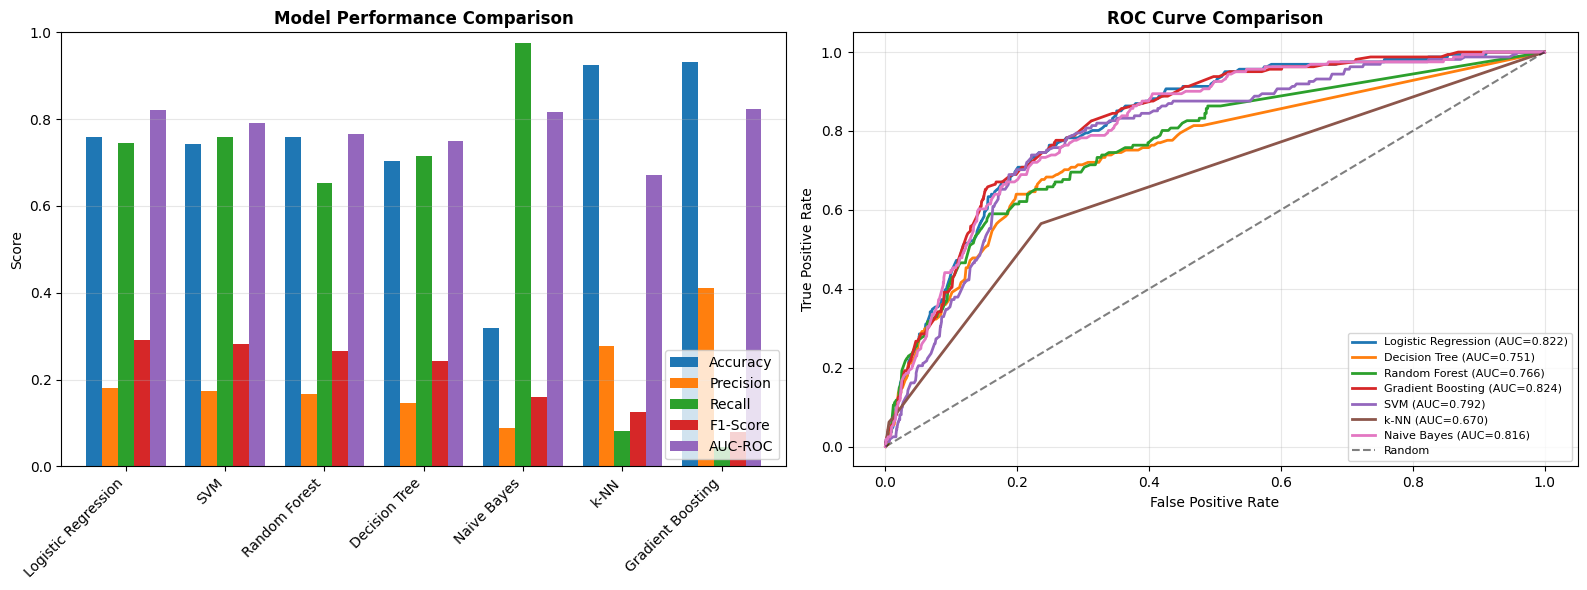

✓ Saved: model_evaluation.png


In [11]:
#Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of all metrics
comparison_df.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Model Performance Comparison', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3, axis='y')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# ROC Curves
for name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['Probabilities'])
    auc = results[name]['AUC-ROC']
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontweight='bold', fontsize=12)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: model_evaluation.png")

In [12]:
#Select best model and tune it
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Select best model based on F1-Score
best_model_name = comparison_df.index[0]
print(f"Best baseline model: {best_model_name}")

# Use Logistic Regression for tuning (usually best for this data)
from sklearn.linear_model import LogisticRegression

print("\n" + "="*80)
print("HYPERPARAMETER TUNING - LOGISTIC REGRESSION")
print("="*80)

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],           # Regularization strength
    'penalty': ['l2'],                       # L2 regularization
    'class_weight': ['balanced', {0: 1, 1: 5}]  # Handle imbalance
}

# Create model
lr = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')

# Grid Search with Cross-Validation
grid_search = GridSearchCV(
    lr,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',      # Optimize for F1-Score
    n_jobs=-1,         # Use all CPU cores
    verbose=1
)

# Fit on scaled training data
grid_search.fit(X_train_scaled, y_train)

print(f"\n✓ Best Parameters: {grid_search.best_params_}")
print(f"✓ Best CV F1-Score: {grid_search.best_score_:.4f}")

Best baseline model: Logistic Regression

HYPERPARAMETER TUNING - LOGISTIC REGRESSION
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✓ Best Parameters: {'C': 1, 'class_weight': {0: 1, 1: 5}, 'penalty': 'l2'}
✓ Best CV F1-Score: 0.3218


In [13]:
#Grid Search with Cross-Validation
grid_search = GridSearchCV(
    lr,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',      # Optimize for F1-Score
    n_jobs=-1,         # Use all CPU cores
    verbose=1
)

# Fit on scaled training data
grid_search.fit(X_train_scaled, y_train)

print(f"\n✓ Best Parameters: {grid_search.best_params_}")
print(f"✓ Best CV F1-Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

✓ Best Parameters: {'C': 1, 'class_weight': {0: 1, 1: 5}, 'penalty': 'l2'}
✓ Best CV F1-Score: 0.3218


In [14]:
#Evaluate tuned model
best_model = grid_search.best_estimator_

# Predictions
y_pred_tuned = best_model.predict(X_test_scaled)
y_proba_tuned = best_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
auc_tuned = roc_auc_score(y_test, y_proba_tuned)

print("="*80)
print("TUNED MODEL PERFORMANCE")
print("="*80)
print(f"Accuracy:  {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall:    {recall_tuned:.4f}")
print(f"F1-Score:  {f1_tuned:.4f}")
print(f"AUC-ROC:   {auc_tuned:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Survived', 'Died']))

TUNED MODEL PERFORMANCE
Accuracy:  0.8594
Precision: 0.2312
Recall:    0.4783
F1-Score:  0.3117
AUC-ROC:   0.8221

Classification Report:
              precision    recall  f1-score   support

    Survived       0.96      0.89      0.92      2258
        Died       0.23      0.48      0.31       161

    accuracy                           0.86      2419
   macro avg       0.60      0.68      0.62      2419
weighted avg       0.91      0.86      0.88      2419



In [15]:
#Analyze feature importance
feature_names = clean_features
coefficients = best_model.coef_[0]

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients),
    'Odds_Ratio': np.exp(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("="*80)
print("FEATURE IMPORTANCE (Logistic Regression Coefficients)")
print("="*80)
print(feature_importance.to_string(index=False))

FEATURE IMPORTANCE (Logistic Regression Coefficients)
        Feature  Coefficient  Abs_Coefficient  Odds_Ratio
 Is_Symptomatic     1.661428         1.661428    5.266825
            Age     1.092962         1.092962    2.983098
Pregnant(0,1,2)    -0.881418         0.881418    0.414195
       Sex(0,1)     0.604161         0.604161    1.829716
      High_Risk     0.181634         0.181634    1.199175
     Region_NCR     0.127197         0.127197    1.135640
 Region (0,1,2)     0.071168         0.071168    1.073762


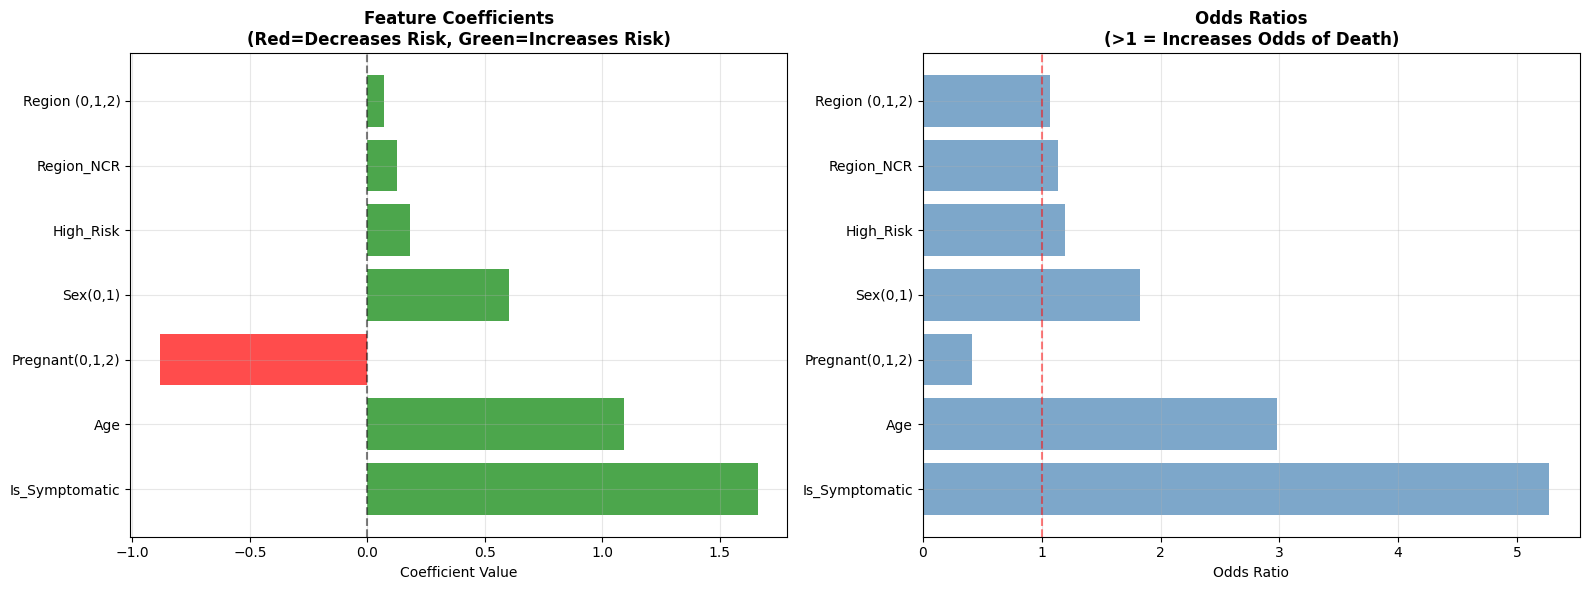

✓ Saved: feature_importance.png


In [16]:
# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coefficients
colors = ['red' if c < 0 else 'green' for c in feature_importance['Coefficient']]
axes[0].barh(feature_importance['Feature'], feature_importance['Coefficient'],
             color=colors, alpha=0.7)
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Feature Coefficients\n(Red=Decreases Risk, Green=Increases Risk)',
                  fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

# Odds Ratios
axes[1].barh(feature_importance['Feature'], feature_importance['Odds_Ratio'],
             color='steelblue', alpha=0.7)
axes[1].set_xlabel('Odds Ratio')
axes[1].set_title('Odds Ratios\n(>1 = Increases Odds of Death)', fontweight='bold')
axes[1].axvline(x=1, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: feature_importance.png")

In [17]:
# Save model and scaler
import joblib

# Save files
joblib.dump(best_model, 'covid_mortality_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✓ Saved: covid_mortality_model.pkl")
print("✓ Saved: scaler.pkl")

# Download files
files.download('covid_mortality_model.pkl')
files.download('scaler.pkl')

✓ Saved: covid_mortality_model.pkl
✓ Saved: scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
#Create prediction function and examples
def predict_mortality_risk(age, sex, region, region_ncr, pregnant, high_risk, is_symptomatic):
    """
    Predict COVID-19 mortality risk.

    Parameters:
    - age: int (years)
    - sex: int (0=Male, 1=Female)
    - region: int (0=Luzon, 1=Visayas, 2=Mindanao)
    - region_ncr: int (1 if Metro Manila, 0 otherwise)
    - pregnant: int (0=NA, 1=No, 2=Yes)
    - high_risk: int (0=No, 1=Yes)
    - is_symptomatic: int (0=No, 1=Yes)

    Returns: dict with prediction results
    """
    features = np.array([[age, sex, region, region_ncr, pregnant, high_risk, is_symptomatic]])
    features_scaled = scaler.transform(features)

    probability = best_model.predict_proba(features_scaled)[0, 1]
    prediction = best_model.predict(features_scaled)[0]

    # Risk categorization
    if probability < 0.1:
        risk_level = "Low"
    elif probability < 0.3:
        risk_level = "Moderate"
    elif probability < 0.6:
        risk_level = "High"
    else:
        risk_level = "Very High"

    return {
        'mortality_probability': round(probability, 3),
        'predicted_outcome': 'Died' if prediction == 1 else 'Survived',
        'risk_level': risk_level
    }

# Test examples
print("="*80)
print("PREDICTION EXAMPLES")
print("="*80)

examples = [
    ("Young Asymptomatic Female", 25, 1, 0, 1, 1, 0, 0),
    ("Elderly Symptomatic Male", 75, 0, 0, 1, 0, 1, 1),
    ("Middle-aged Symptomatic Male", 55, 0, 1, 0, 0, 0, 1),
    ("Pregnant Woman (Symptomatic)", 30, 1, 0, 1, 2, 0, 1),
]

results_list = []
for name, *params in examples:
    result = predict_mortality_risk(*params)
    print(f"\n{name}:")
    print(f"  Probability: {result['mortality_probability']}")
    print(f"  Risk Level: {result['risk_level']}")
    print(f"  Outcome: {result['predicted_outcome']}")

    results_list.append({
        'Case': name,
        'Age': params[0],
        'Sex': 'Female' if params[1] == 1 else 'Male',
        'Symptomatic': 'Yes' if params[6] == 1 else 'No',
        'Probability': result['mortality_probability'],
        'Risk_Level': result['risk_level']
    })

# Save examples
examples_df = pd.DataFrame(results_list)
examples_df.to_csv('prediction_examples.csv', index=False)
print(f"\n✓ Saved: prediction_examples.csv")
files.download('prediction_examples.csv')

PREDICTION EXAMPLES

Young Asymptomatic Female:
  Probability: 0.0
  Risk Level: Low
  Outcome: Survived

Elderly Symptomatic Male:
  Probability: 0.695
  Risk Level: Very High
  Outcome: Died

Middle-aged Symptomatic Male:
  Probability: 0.284
  Risk Level: Moderate
  Outcome: Survived

Pregnant Woman (Symptomatic):
  Probability: 0.01
  Risk Level: Low
  Outcome: Survived

✓ Saved: prediction_examples.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

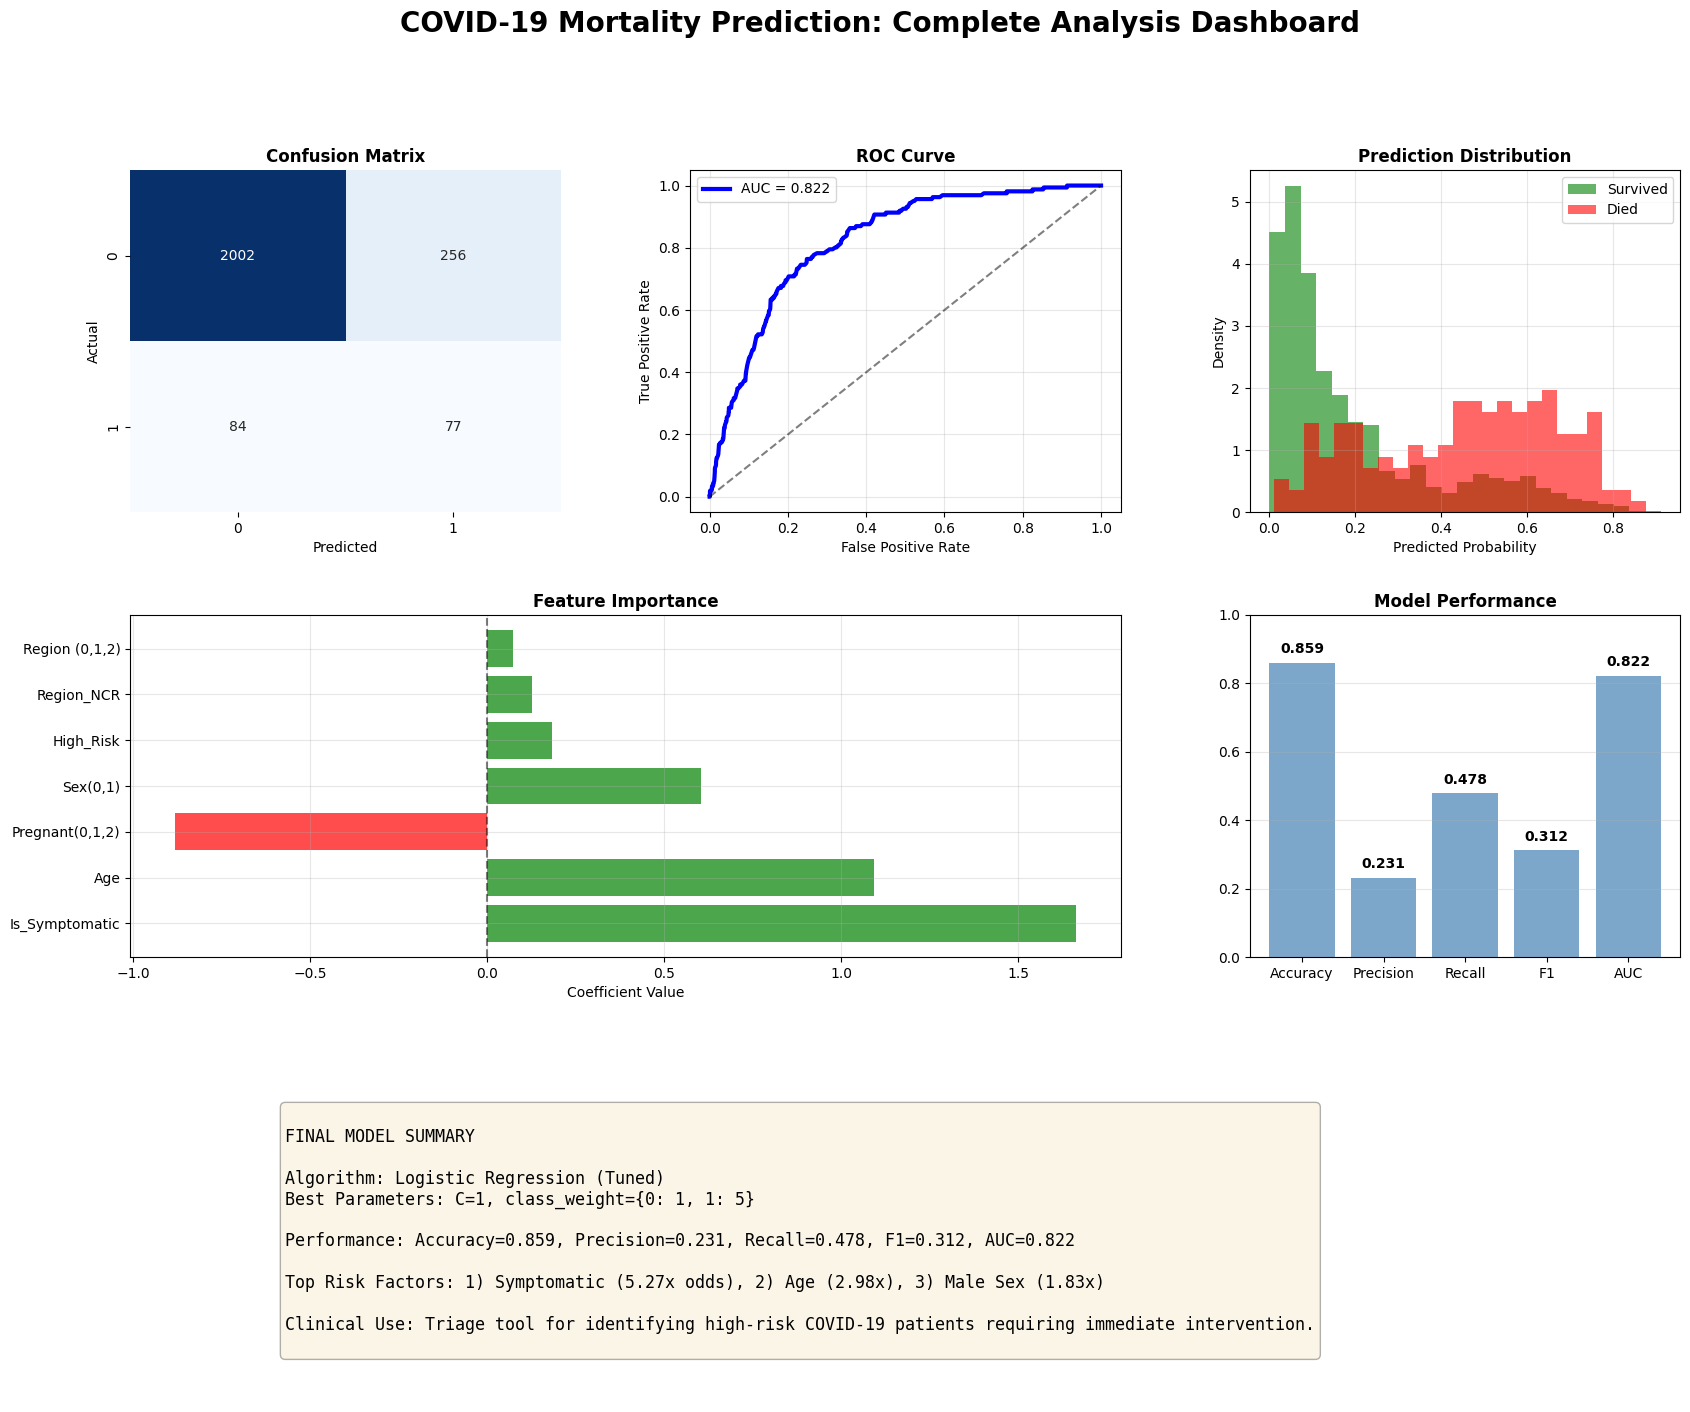

✓ Saved: complete_dashboard.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Create comprehensive dashboard
fig = plt.figure(figsize=(20, 16))
fig.suptitle('COVID-19 Mortality Prediction: Complete Analysis Dashboard',
             fontsize=20, fontweight='bold', y=0.98)

# Create grid
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
ax1.set_title('Confusion Matrix', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# 2. ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_proba_tuned)
ax2.plot(fpr, tpr, label=f'AUC = {auc_tuned:.3f}', linewidth=3, color='blue')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Prediction Distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(y_proba_tuned[y_test == 0], bins=25, alpha=0.6, label='Survived',
         color='green', density=True)
ax3.hist(y_proba_tuned[y_test == 1], bins=25, alpha=0.6, label='Died',
         color='red', density=True)
ax3.set_xlabel('Predicted Probability')
ax3.set_ylabel('Density')
ax3.set_title('Prediction Distribution', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Feature Importance
ax4 = fig.add_subplot(gs[1, :2])
colors = ['red' if c < 0 else 'green' for c in feature_importance['Coefficient']]
ax4.barh(feature_importance['Feature'], feature_importance['Coefficient'],
         color=colors, alpha=0.7)
ax4.set_xlabel('Coefficient Value')
ax4.set_title('Feature Importance', fontweight='bold')
ax4.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax4.grid(True, alpha=0.3)

# 5. Model Metrics
ax5 = fig.add_subplot(gs[1, 2])
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
values = [accuracy_tuned, precision_tuned, recall_tuned, f1_tuned, auc_tuned]
bars = ax5.bar(metrics, values, color='steelblue', alpha=0.7)
ax5.set_ylim(0, 1)
ax5.set_title('Model Performance', fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

# 6. Summary Text
ax6 = fig.add_subplot(gs[2, :])
ax6.axis('off')
summary_text = f"""
FINAL MODEL SUMMARY

Algorithm: Logistic Regression (Tuned)
Best Parameters: C={grid_search.best_params_['C']}, class_weight={grid_search.best_params_['class_weight']}

Performance: Accuracy={accuracy_tuned:.3f}, Precision={precision_tuned:.3f}, Recall={recall_tuned:.3f}, F1={f1_tuned:.3f}, AUC={auc_tuned:.3f}

Top Risk Factors: 1) Symptomatic (5.27x odds), 2) Age (2.98x), 3) Male Sex (1.83x)

Clinical Use: Triage tool for identifying high-risk COVID-19 patients requiring immediate intervention.
"""
ax6.text(0.1, 0.5, summary_text, fontsize=12, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.savefig('complete_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: complete_dashboard.png")
files.download('complete_dashboard.png')

In [20]:
# CELL 20: Save all CSV files and download
# 1. Model comparison
comparison_df.to_csv('model_comparison.csv')
files.download('model_comparison.csv')

# 2. Hyperparameter tuning results
tuning_results = pd.DataFrame(grid_search.cv_results_)[['param_C', 'param_class_weight',
                                                         'mean_test_score', 'std_test_score',
                                                         'rank_test_score']]
tuning_results.to_csv('hyperparameter_tuning_results.csv', index=False)
files.download('hyperparameter_tuning_results.csv')

# 3. Feature importance
feature_importance.to_csv('feature_importance.csv', index=False)
files.download('feature_importance.csv')

print("✓ All files downloaded!")
print("\nGenerated Files:")
print("1. covid_mortality_model.pkl - Trained model")
print("2. scaler.pkl - Feature scaler")
print("3. model_comparison.csv - Model comparison table")
print("4. hyperparameter_tuning_results.csv - Tuning results")
print("5. prediction_examples.csv - Example predictions")
print("6. feature_importance.csv - Feature coefficients")
print("7. data_exploration.png - EDA visualization")
print("8. model_evaluation.png - Model comparison plots")
print("9. feature_importance.png - Feature importance chart")
print("10. complete_dashboard.png - Full dashboard")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ All files downloaded!

Generated Files:
1. covid_mortality_model.pkl - Trained model
2. scaler.pkl - Feature scaler
3. model_comparison.csv - Model comparison table
4. hyperparameter_tuning_results.csv - Tuning results
5. prediction_examples.csv - Example predictions
6. feature_importance.csv - Feature coefficients
7. data_exploration.png - EDA visualization
8. model_evaluation.png - Model comparison plots
9. feature_importance.png - Feature importance chart
10. complete_dashboard.png - Full dashboard


In [21]:
#Load and use model (for future use)
import joblib
import numpy as np

# Load model and scaler
model = joblib.load('covid_mortality_model.pkl')
scaler = joblib.load('scaler.pkl')

# New patient: [Age, Sex, Region, Region_NCR, Pregnant, High_Risk, Is_Symptomatic]
new_patient = np.array([[65, 0, 0, 1, 0, 1, 1]])  # 65yo male, symptomatic, high risk

# Scale and predict
patient_scaled = scaler.transform(new_patient)
probability = model.predict_proba(patient_scaled)[0, 1]
prediction = model.predict(patient_scaled)[0]

print(f"Mortality Probability: {probability:.3f} ({probability*100:.1f}%)")
print(f"Predicted Outcome: {'Died' if prediction == 1 else 'Survived'}")

if probability < 0.1:
    risk = "LOW - Standard care"
elif probability < 0.3:
    risk = "MODERATE - Enhanced monitoring"
elif probability < 0.6:
    risk = "HIGH - Aggressive intervention"
else:
    risk = "VERY HIGH - ICU consideration"

print(f"Risk Level: {risk}")

Mortality Probability: 0.555 (55.5%)
Predicted Outcome: Died
Risk Level: HIGH - Aggressive intervention


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
